# Customer Churn Prediction Using Machine Learning

## Introduction

Customer churn refers to customers discontinuing their services with a company. Predicting churn can help businesses identify customers who may be at risk of leaving and understand the factors associated with customer retention.

In this project, customer information such as demographic characteristics, subscribed services, contract details, payment methods, and billing information is analysed. Machine learning classification techniques are then used to predict whether a customer is likely to churn.

## Objective

The main objectives of this project are:

- To understand the structure and characteristics of the customer churn dataset.
- To analyse customer characteristics and service-related factors associated with churn.
- To clean and prepare the data for machine learning.
- To transform categorical and numerical variables into a suitable format.
- To build classification models for predicting customer churn.
- To evaluate the performance of the models using appropriate classification metrics.
- To compare the models and identify the better-performing approach.

In [63]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib and Seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading

The customer churn dataset is loaded into a pandas DataFrame. Loading the dataset into a DataFrame allows the customer records and their associated variables to be inspected and analysed using Python.

In [64]:
# Load the customer churn dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Initial Data Inspection

The dimensions of the dataset are examined to determine the number of customer records and variables available for analysis.

In [65]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


### Column and Data Type Inspection

The column names and data types are examined to understand the structure of the dataset. This step is particularly important because customer churn datasets commonly contain a mixture of numerical and categorical variables.

In [66]:
# Display column names
print("Columns:")
print(df.columns.tolist())

# Display data types and non-null information
print("\nDataset information:")
df.info()

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity  

## 3. Missing Value Analysis

Missing values can affect exploratory analysis and machine learning models. Therefore, the number of missing values in each column is checked before further processing.

In [67]:
# Count missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 4. Churn Distribution

The `Churn` variable is the target variable for this project. It indicates whether a customer has left the company.

The distribution of the target variable is examined to understand how many customers belong to each churn category. This is useful for identifying whether the target classes are reasonably balanced or whether there is a noticeable difference between them.

In [68]:
# Count customers in each churn category
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


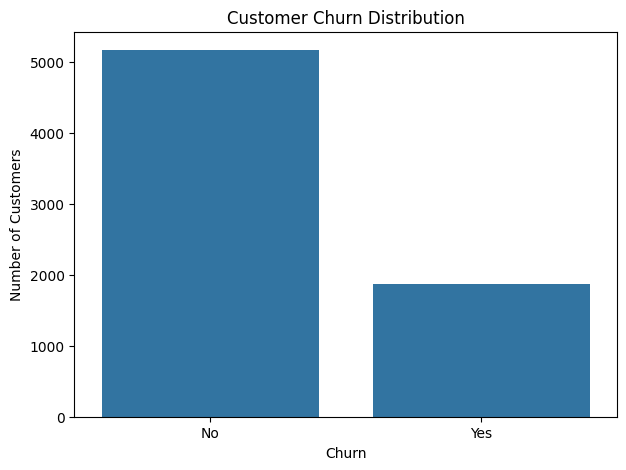

In [69]:
# Visualize the distribution of churn
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The distribution shows the number of customers who stayed with the company compared with those who churned. The difference between the two categories should be considered when evaluating the classification models, since an uneven target distribution can affect model performance.

## 5. Categorical Feature Analysis

The dataset contains several categorical variables describing customer demographics, subscribed services, contract information, and payment methods.

The unique categories in these variables are examined to understand how the information is represented and to identify variables that may be useful for predicting customer churn.

In [70]:
# Display unique values for each categorical column
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


## 6. Numerical Feature Analysis

The numerical variables are examined using descriptive statistics. Measures such as the mean, standard deviation, minimum, maximum, and quartiles provide an overview of the numerical characteristics of the customers in the dataset.

In [71]:
# Identify numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical features:")
print(numeric_columns.tolist())

# Display descriptive statistics
df[numeric_columns].describe()

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observation

The descriptive statistics provide an overview of the numerical customer characteristics and their ranges. These values will help identify differences in scale between numerical variables before the data is prepared for machine learning.

## 7. Churn Across Contract Types

Contract duration can influence customer retention because customers with different contract arrangements may have different levels of commitment to the service.

The churn distribution is therefore examined across the available contract types.

In [72]:
# Calculate churn percentage within each contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


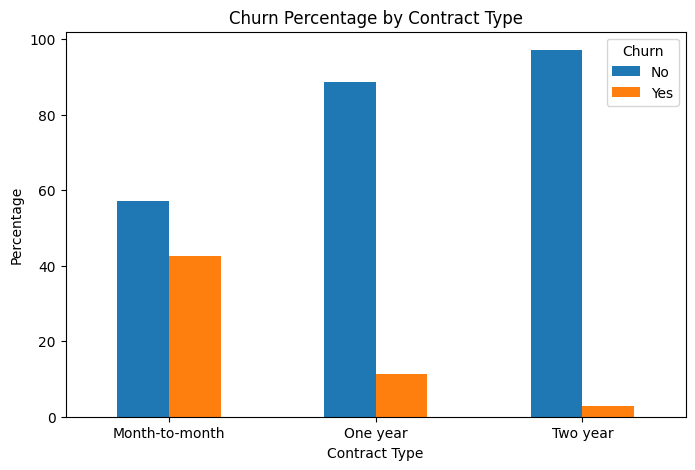

In [73]:
# Visualize churn percentage by contract type
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

### Observation

The churn percentages differ across contract types. This indicates that contract arrangement may be associated with customer retention and could therefore provide useful information for the churn prediction models.

## 8. Churn Across Payment Methods

Payment method is another customer-related characteristic that may be associated with churn. The churn distribution is examined across the different payment methods available in the dataset.

In [74]:
# Calculate churn percentage for each payment method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


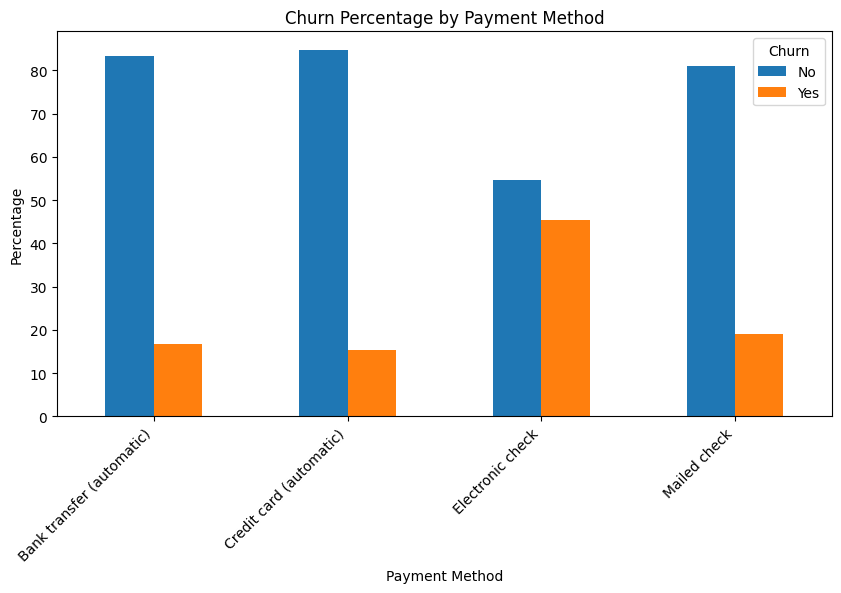

In [75]:
# Visualize churn percentage by payment method
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Churn")

plt.show()

### Observation

The churn distribution varies across payment methods. These differences suggest that payment-related characteristics may contain useful information for distinguishing customers who churn from those who remain with the company.

## 9. Customer Tenure and Churn

Customer tenure represents the length of time a customer has remained with the company. Examining tenure across churn categories can help identify whether newer or longer-term customers show different churn patterns.

In [76]:
# Compare average tenure between churn categories
tenure_by_churn = df.groupby("Churn")["tenure"].mean()

print(tenure_by_churn)

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


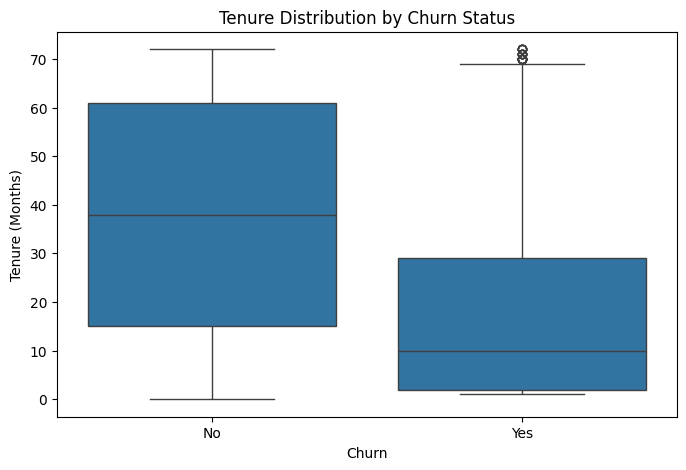

In [77]:
# Visualize tenure distribution by churn status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Observation

The tenure distributions show how customer length of service differs between churn categories. The box plot provides a clearer view of the central tendency and spread of tenure for customers who churned and those who remained.

## 10. Data Cleaning and Preparation

Before applying machine learning algorithms, the dataset is checked for data-type inconsistencies and values that may require conversion or cleaning.

Particular attention is given to numerical variables that may have been stored as text. Correct data types are necessary for numerical analysis and model preprocessing.

In [78]:
# Display the data types of all columns
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [79]:
# Check the data type and unique values of TotalCharges
print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Blank TotalCharges values:", (df["TotalCharges"] == " ").sum())

TotalCharges data type: object
Blank TotalCharges values: 11


### Converting Total Charges

The `TotalCharges` variable represents the total amount charged to a customer. If it is stored as text, it must be converted into a numerical format before it can be used as a numerical machine learning feature.

Blank values, if present, are converted to missing values during this process.

In [80]:
# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check the resulting data type
print("TotalCharges data type:", df["TotalCharges"].dtype)

TotalCharges data type: float64


### Missing Values After Data Conversion

After converting `TotalCharges` into a numerical variable, the dataset is checked again for missing values. This ensures that any values that could not be converted are identified before model training.

In [81]:
# Check missing values after converting TotalCharges
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


### Handling Missing Total Charges

The conversion of `TotalCharges` may result in a small number of missing values where the original dataset contained blank entries. These records are removed because `TotalCharges` is required as a numerical feature for the machine learning models.

In [82]:
# Remove rows with missing TotalCharges values
df = df.dropna(subset=["TotalCharges"])

# Check the number of remaining records
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [83]:
# Confirm that no missing values remain
print(df.isnull().sum().sum())

0


## 11. Feature Selection

The customer identification number is not used as a predictive feature because it serves only as an identifier for individual customers. Including such an identifier could add unnecessary information without contributing meaningful customer behaviour patterns to the model.

The `customerID` column is therefore removed before model training.

In [84]:
# Remove the customer identifier
df = df.drop("customerID", axis=1)

# Display the remaining columns
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Separating Features and Target

The `Churn` column is the target variable because it represents whether a customer left the company.

All remaining columns are treated as input features that may contain information useful for predicting customer churn.

In [85]:
# Separate input features and target variable
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


### Identifying Numerical and Categorical Features

The input variables are divided into numerical and categorical features. This is necessary because the two types of variables require different preprocessing techniques before they can be used by the machine learning models.

In [86]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Observation

The dataset contains both numerical and categorical customer characteristics. Numerical variables can be standardized, while categorical variables need to be converted into numerical representations before model training.

## 12. Train-Test Split

The dataset is divided into training and testing subsets. The training data is used to develop the classification models, while the testing data is kept separate for evaluating their performance on unseen customer records.

An 80:20 split is used, with stratification applied to preserve the distribution of the two churn classes in both subsets.

In [87]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5625, 19)
Testing features: (1407, 19)
Training target: (5625,)
Testing target: (1407,)


### Observation

The dataset has been divided into training and testing subsets using an 80:20 ratio. The test set will remain separate and will only be used to evaluate the final model predictions.

## 13. Data Preprocessing

The machine learning models require the input variables to be represented in a suitable numerical format.

Categorical variables are converted into numerical features using one-hot encoding, while numerical variables are standardized using `StandardScaler`.

The preprocessing steps are fitted using the training data and then applied to both the training and testing data.

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numeric_features
        )
    ]
)

# Fit preprocessing on training data and transform both datasets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5625, 45)
Processed testing shape: (1407, 45)


### Observation

After preprocessing, the categorical variables have been converted into numerical features and the numerical variables have been standardized. The resulting processed feature matrices are now ready for machine learning model development.

## 14. Logistic Regression Model

Logistic Regression is used as the first classification model for predicting customer churn. It provides a baseline approach for distinguishing between customers who churned and customers who remained with the company.

The model is trained using the preprocessed training data and is then used to predict churn for the unseen test observations.

In [89]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Predictions

After training, the Logistic Regression model is used to predict whether each customer in the test dataset is likely to churn.

In [90]:
# Generate predictions for the test dataset
y_pred = logistic_model.predict(X_test_processed)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']


### Model Evaluation

The model is first evaluated using accuracy, which represents the proportion of test observations that were classified correctly.

In [91]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8038379530916845
Accuracy (%): 80.38379530916845


### Classification Report

The classification report provides precision, recall, and F1-score for both churn classes. These metrics provide a more detailed view of model performance than accuracy alone.

In [92]:
from sklearn.metrics import classification_report

# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each churn category. It helps identify whether the model is better at identifying customers who stay or customers who churn.

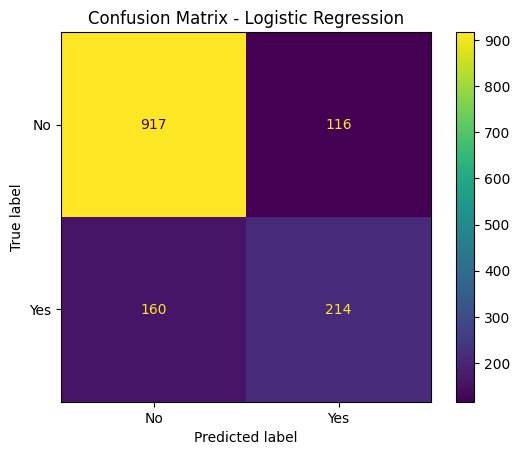

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

The Logistic Regression model achieved an accuracy of approximately 80.38% on the test dataset, indicating that it correctly classified most of the customer records.

The classification report shows that the model performed better for customers who did not churn than for customers who churned. The recall for the `Yes` class is lower than the recall for the `No` class, which means that some customers who actually churned were not identified by the model.

The confusion matrix also shows the correct and incorrect predictions for both churn categories. Therefore, although the model provides a reasonable baseline for customer churn prediction, there is still room for improvement, particularly in identifying customers who are likely to churn.

## 15. Decision Tree Model

A Decision Tree classifier is used as a second machine learning approach for predicting customer churn. Unlike Logistic Regression, a Decision Tree makes predictions by creating a series of decision rules based on the input features.

The Decision Tree is trained using the same training and testing data used for Logistic Regression so that the performance of the two models can be compared fairly.

In [94]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

### Predictions

After training, the Decision Tree model is used to predict the churn status of customers in the test dataset.

In [95]:
# Generate predictions using the Decision Tree
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred_tree[:20])

First 20 predictions:
['No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'Yes' 'No' 'No' 'No' 'No']


### Model Evaluation

The Decision Tree is first evaluated using accuracy to determine the proportion of test observations that were classified correctly.

In [96]:
# Calculate Decision Tree accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy (%):", tree_accuracy * 100)

Decision Tree Accuracy: 0.7213930348258707
Decision Tree Accuracy (%): 72.13930348258707


### Classification Report

The classification report provides precision, recall, and F1-score for both churn classes. These metrics give a more detailed evaluation of the Decision Tree model beyond accuracy alone.

In [97]:
from sklearn.metrics import classification_report

# Display the classification report for the Decision Tree
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

          No       0.81      0.80      0.81      1033
         Yes       0.48      0.49      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



### Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Decision Tree model for both churn categories. It helps to understand how well the model identifies customers who stayed with the company and customers who churned.

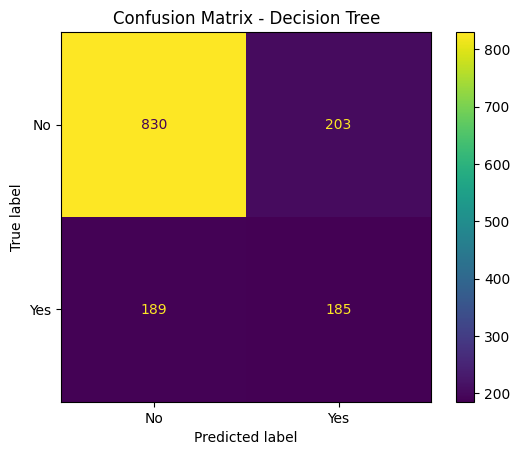

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=["No", "Yes"]
)

# Display the confusion matrix
disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["No", "Yes"]
)

disp_tree.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Observation

The Decision Tree model achieved an accuracy of approximately 72.14% on the test dataset. The classification report shows that the model performed better for customers who did not churn than for customers who churned. In particular, the recall for the Yes class is lower, meaning that the model misses a number of customers who actually churned.

Compared with the Logistic Regression model, the Decision Tree has lower accuracy and weaker performance for identifying customers who churn. Therefore, based on the results obtained in this project, Logistic Regression provides the better overall classification performance.

## 16. Results and Interpretation

The two machine learning models were evaluated on the same test dataset to compare their classification performance.

Logistic Regression achieved an accuracy of approximately 80.38%, while the Decision Tree achieved an accuracy of approximately 72.14%. Based on accuracy, Logistic Regression performed better on this dataset.

The classification reports also show that both models performed better at identifying customers who did not churn than customers who churned. Logistic Regression achieved a recall of 0.57 for the Yes class, while the Decision Tree achieved a recall of 0.49.

This indicates that identifying customers who are likely to churn is more challenging than identifying customers who remain with the company. Therefore, accuracy alone does not provide the complete picture of model performance.

Overall, Logistic Regression was the better-performing model among the two models tested because it achieved higher accuracy and better performance for the churn class.

In [99]:
# Create a comparison of the two models
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy]
})

# Display the comparison
print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.803838
1        Decision Tree  0.721393


The accuracy of the two machine learning models is visualized below to provide a clear comparison of their classification performance.

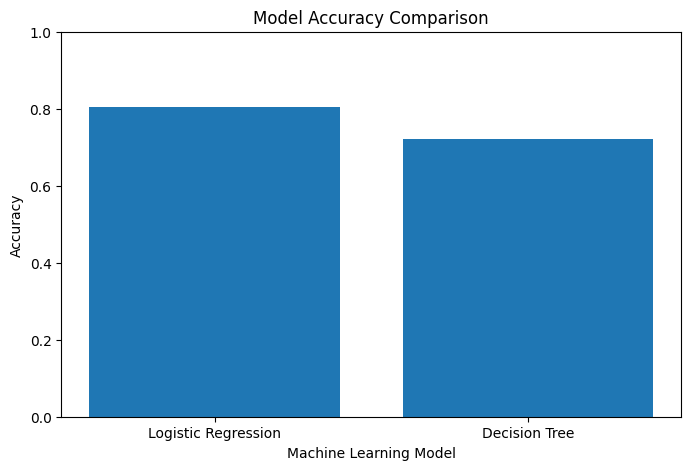

In [100]:
# Visualize the accuracy of the two machine learning models

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

### Model Comparison Observation

The comparison shows that Logistic Regression achieved the higher test accuracy of approximately 80.38%, compared with 72.14% for the Decision Tree.

Therefore, Logistic Regression is selected as the better-performing model for this dataset based on the evaluation results.

## 17. Conclusion

This project used machine learning techniques to predict customer churn. The dataset was explored and cleaned before the customer information was prepared for modelling. Numerical and categorical variables were appropriately processed so that they could be used by the classification algorithms.

Two classification models, Logistic Regression and Decision Tree, were developed and evaluated using the same test dataset. Logistic Regression achieved an accuracy of approximately 80.38%, while the Decision Tree achieved approximately 72.14%.

Although both models were able to identify customers who remained with the company reasonably well, identifying customers who actually churned was more challenging. This was reflected in the lower recall for the Yes class in both models.

Based on the results obtained, Logistic Regression was selected as the better-performing model. The findings suggest that machine learning can provide useful information for identifying customer churn patterns, although further improvements could be explored to improve the identification of customers who are likely to leave.